
    curvatures_sub = (labels_sub, curv_in_sub, curv_rec_sub, curv_lat_sub, curv_lat_norm_sub, curv_true,curv_learned)
    curvatures_emp_full = (labels, curv_in, curv_lat, curv_lat_norm, curv_rec)


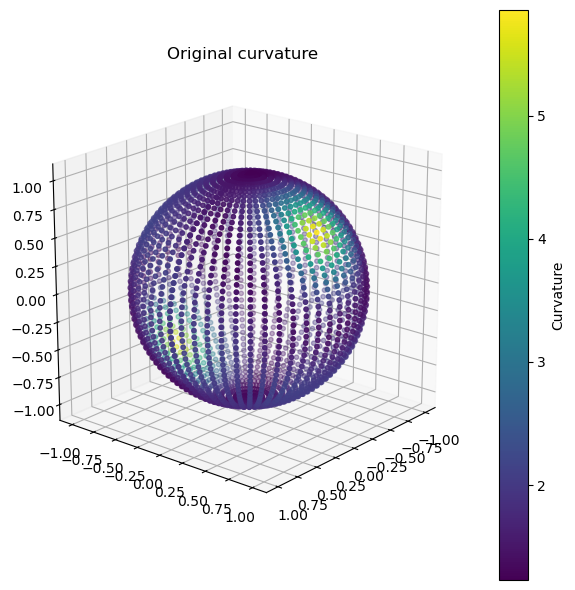

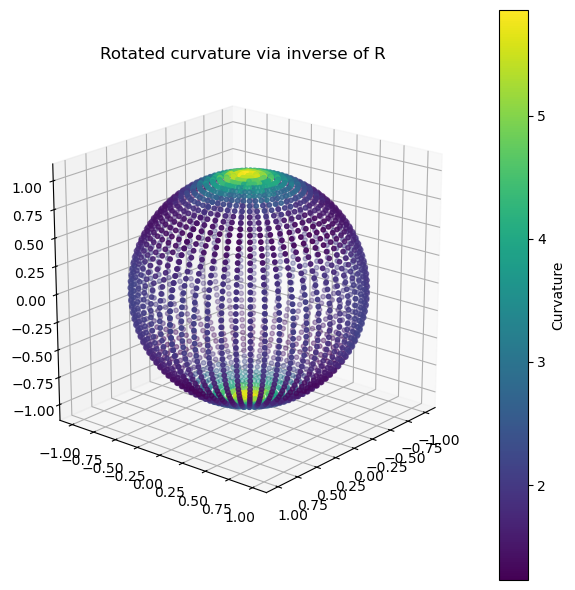


Metric comparison with ground truth:
Before MSE:   2.267753
Before SMAPE: 40.09 %
After MSE:   0.302872
After SMAPE: 16.97 %


In [41]:
import torch
import math
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from scipy.spatial import cKDTree

def cartesian_to_spherical(z):
    z = z / z.norm(dim=1, keepdim=True)
    x, y, z_coord = z[:,0], z[:,1], z[:,2]
    theta = torch.acos(z_coord.clamp(-1.0, 1.0))
    phi = torch.atan2(y, x)
    return theta, phi

def spherical_to_cartesian(theta, phi):
    x = torch.sin(theta) * torch.cos(phi)
    y = torch.sin(theta) * torch.sin(phi)
    z = torch.cos(theta)
    return torch.stack([x, y, z], dim=1)

def compute_rotation_matrix(source, target, weights):
    W = torch.diag(weights)
    A = source.T @ W @ target
    U, _, Vt = torch.svd(A)
    R = Vt @ U.T
    if torch.det(R) < 0:
        Vt[-1, :] *= -1
        R = Vt @ U.T
    return R

def plot_sphere_vectors(vectors, weights, title):
    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(111, projection='3d')
    sc = ax.scatter(vectors[:,0], vectors[:,1], vectors[:,2],
                    c=weights, cmap='viridis', s=10)
    plt.colorbar(sc, ax=ax, label="Curvature")
    ax.set_title(title)
    ax.set_box_aspect([1,1,1])
    ax.view_init(elev=20, azim=40)
    plt.tight_layout()
    plt.show()

def load_data(path):
    data = torch.load(path, map_location='cpu', weights_only=False)
    latents = data["points_sub"][1].float()
    label_angles = data["curvatures_sub"][0].float()
    curvature_weights = data["curvatures_sub"][6].float()
    ground_truth = data["curvatures_sub"][5].float()
    return latents, label_angles, curvature_weights, ground_truth

def build_spherical_grid(num_points):
    eps = 1e-4
    n = int(np.sqrt(num_points))
    thetas = torch.linspace(0.01, torch.pi - eps, n)
    phis = torch.linspace(eps, 2 * torch.pi - eps, n)
    grid_angles = torch.cartesian_prod(thetas, phis)
    vecs = spherical_to_cartesian(grid_angles[:, 0], grid_angles[:, 1])
    return vecs, grid_angles

def rotate_curvature_function(vecs, R, curvature_weights):
    vecs_rotated = vecs @ R
    tree = cKDTree(vecs.numpy())
    _, nn_indices = tree.query(vecs_rotated.numpy(), k=1)
    return curvature_weights[nn_indices]

def mse(a, b):
    return torch.mean((a - b)**2).item()

def smape(a, b, eps=1e-8):
    return 100 * torch.mean(2 * torch.abs(a - b) / (torch.abs(a) + torch.abs(b) + eps)).item()

def evaluate_metrics(estimate, ground_truth, label):
    print(f"{label} MSE:   {mse(estimate, ground_truth):.6f}")
    print(f"{label} SMAPE: {smape(estimate, ground_truth):.2f} %")

def run_alignment_and_rotate_curvature(path):
    latents, label_angles, curvature_weights, ground_truth = load_data(path)
    vecs, _ = build_spherical_grid(len(curvature_weights))

    plot_sphere_vectors(vecs, curvature_weights, "Original curvature")

    label_cartesian = spherical_to_cartesian(label_angles[:, 0], label_angles[:, 1])
    R = compute_rotation_matrix(latents, label_cartesian, curvature_weights)

    rotated_curvature = rotate_curvature_function(vecs, R, curvature_weights)

    plot_sphere_vectors(vecs, rotated_curvature, "Rotated curvature via inverse of R")

    print("\nMetric comparison with ground truth:")
    evaluate_metrics(curvature_weights, ground_truth, "Before")
    evaluate_metrics(rotated_curvature, ground_truth, "After")

def main():
    path = "notebooks_m_vae/curvatures/curvatures_exp00_vae_s2_synthetic.pt"
    run_alignment_and_rotate_curvature(path)

if __name__ == "__main__":
    main()
